In [1]:
import pandas as pd
from results import combine_results, process_results, confusion_matrix, data_process, process_as_binary, score_results, score_results_RMSE, score_results_MAE, score_results_spearman
import json 
import re


In [48]:
edit_path = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/TEST_SEMANTIC_NO_RELEVANCE/predictions_10_OPENAI-2048-COSINE.jsonl'
#edit_path = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/KG_NO_SEM_TEST/predictions_10_OPENAI-2048-COSINE.jsonl'

In [49]:
data = []
with open(edit_path, 'r') as file:
    for line in file:
        data.append(json.loads(line))

In [42]:
JSON_SCHEMAS = [{"Court":"string (Committee, Chamber or Grand Chamber)","Reasoning":"string (give your reason for the importance)" }]


In [43]:
court_levels = '''Committee: A Committee consists of 3 judges. The Committee can rule on the merits of a case where the Court's case law is well established. They can also rule on the admissibility of a case with well established case law.; 
                                   Chamber: A Chamber consists of 7 judges. The Chamber can can decide on the merits or admissibility of a case if no prior decision has been reached by the Committee or a single judge. The Chamber can relinquish jurisdiction to the Grand Chamber.;
                                   Grand Chamber: The Grand Chamber consists of 17 judges. It examines the cases that are submitted to it either after a Chamber has relinquished jurisdiction or when a request for referral of the case has been granted by the Grand Chamber Panel. The Grand Chambers deals with cases which raise a serious question affecting the interpretation of the Convention or if there is a risk that its resolution of the case would be inconsistent with a judgment previously delivered by the Court. 
                                '''

In [35]:
pkl_path = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/TEST_SEMANTIC_NO_RELEVANCE/final_examples_10_OPENAI-2048-COSINE_EXAMPLE_DICT.pkl'
#pkl_path = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/KG_NO_SEM_TEST/final_examples_10_OPENAI-2048-COSINE_EXAMPLE_DICT.pkl'
cases = pd.read_pickle(pkl_path)
outcome_summaries = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/Summarize_Cases/Results/outcome_summaries.pkl')
outcome_cases_0 = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/Art_3_Data_Process/outcome_cases.pkl')
outcome_cases = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/Art_3_Data_Process/outcome_cases_for_network.pkl')

In [45]:
level = 'Committee, Chamber or Grand Chamber'

     
start_prompt = f'''You are a lawyer in the European Court of Human Rights, and your goal is to predict whether a case will end up at the level of {level}; based on information provided from a communicated case.'''


In [51]:
df = pd.DataFrame(data)

for index, row in df.iterrows():
    fileNo = row['custom_id']
    #print(row['body']['messages'][0]['content'])
    rel_cases = list(cases[fileNo])
    
    court_level_list = []
    for i in rel_cases:
        file_number = outcome_summaries[outcome_summaries['500 Word Summary'] == i]['Filename'].values
        if len(file_number) > 0:
            print(file_number[0])
        else:
            print("No match found")
            
        court_level_list.append(outcome_cases[outcome_cases['File'] == file_number[0]]['doctypebranch'].iloc[0])
    
    #map court level list
    court_level_list = list(map(lambda x: 'Committee' if x == 'ADMISSIBILITYCOM' or x=='COMMITTEE' else 'Chamber' if x == 'CHAMBER' or x=='ADMISSIBILITY' else 'Grand Chamber', court_level_list))
    
    row['body']['messages'][0]['content'] = row['body']['messages'][0]['content'].replace(
         "{'Case Importance': 'string (select one of: key_case, 1, 2, 3)', 'Reasoning': 'string (give your reason for the importance)'}", 
         str(JSON_SCHEMAS[0]))
    
    row['body']['messages'][0]['content'] = row['body']['messages'][0]['content'].replace('''You are a lawyer in the European Court of Human Rights, and your goal is to predict the importance of a case, based on information provided from a communicated case. Importance in a legal setting refers to the significance of a case in terms of its impact on the development of case law.''',
                                                                                            start_prompt)
    
    row['body']['messages'][0]['content'] = row['body']['messages'][0]['content'].replace('''You are given a description of the different levels of importance: key_case: These are the most important and have been selected as key cases and have been selected for publication in the Court's official reports; 
                               1: The case is of high importance. The case makes a significant contribution to the development, clarification or modification of its case law, either generally or in relation to a particular case; 
                               2: The case is of medium importance. The case while not making a significant contribution to the case-law, nevertheless it goes beyond merely applying existing case law; 
                               3: The case is of low importance. The case is of limited interest and simply applies existing case law.''',court_levels)
    
    row['body']['messages'][0]['content'] = row['body']['messages'][0]['content'].replace('You are also given summaries of a number of relevant cases and their importance levels',
                                                                                            f'You are also given summaries of a number of relevant cases and their court levels')
    #replace importance level with court level
    for idx, level in enumerate(court_level_list):
        row['body']['messages'][0]['content'] = re.sub(
            r'The importance level for that case was (\d|key_case)',
            f'The court level for that case was {level}',
            row['body']['messages'][0]['content'],
            count=1
        )
        
    row['body']['messages'][0]['content'] = row['body']['messages'][0]['content'].replace('''Based on the information given to you predict the importance of the case according to the criteria given. 
        If you do not know the importance, state that you do not have enough information.''','''Based on the information given to you predict the court level of the case according to the criteria given. 
        If you do not know the court level, state that you do not have enough information.''')
    #print(row['body']['messages'][0]['content'])
    
    row['body']['max_tokens'] = 2048
    



001-22777
001-66627
001-75470
001-108936
001-167086
001-198301
001-179826
001-208879
001-220012
001-223657
001-5170
001-66761
001-72600
001-75430
001-75961
001-80358
001-108936
001-114455
001-144931
001-186115
001-22777
001-75961
001-81024
001-108936
001-103645
001-112146
001-70865
001-83120
001-147615
001-147685
001-5170
001-22720
001-66761
001-80358
001-92955
001-106542
001-126568
001-150829
001-114455
001-219067
001-5671
001-5971
001-22248
001-22902
001-82364
001-100480
001-116674
001-127773
001-58900
001-96773
001-5170
001-66627
001-72600
001-75430
001-75961
001-80358
001-109116
001-114455
001-144931
001-186115
001-66627
001-75430
001-75470
001-95533
001-60778
001-106446
001-114455
001-115204
001-152625
001-179826
001-72600
001-75430
001-76563
001-80358
001-102282
001-114455
001-118582
001-144931
001-160406
001-186115
001-68828
001-77179
001-92955
001-106542
001-116814
001-150848
001-159869
001-109116
001-114455
001-145580
001-66627
001-75430
001-76563
001-80358
001-60778
001-69457

In [52]:
output_filepath = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/Court_label/sem_search_k_10.jsonl'

with open(output_filepath, 'w') as file:
    counter = 0
    for record in df.to_dict(orient='records'):
        file.write(json.dumps(record) + '\n')

In [2]:
#generate zero shot

test_data = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/VectorDB/test.pkl')

In [4]:
test_data.sort_values(by='doc_date', ascending=False, inplace=True)

In [5]:
test_data

,Filename,Questions,Subject Matter,appno,source_file,doc_date,importance,keywords_art_3,keywords_art_3_text,Subj_Count,extracted_apps,new_list_length,new_list_length_2
1027,001-221960,1. Were the applicants submitted to treatment ...,The applicants are practising advocates. They ...,51984/17,pruned_COMMITTEE_meta.json,2024-05-16,4,"[350, 596, 90, 193]","(Art. 3) Prohibition of torture, (Art. 3) Effe...",112,"[54217/16, 16483/12, 22978/05, 15741/15, 39630...",7,5
593,001-158174,1. Were the applicants subjected to inhuman an...,1. A list of the applicants is set out in the ...,14797/11,pruned_COMMITTEE_meta.json,2024-05-16,4,"[350, 596]","(Art. 3) Prohibition of torture, (Art. 3) Effe...",1371,"[39326/02, 23380/09, 71156/01, 28490/02]",5,4
1006,001-215047,In the light of the applicants’ claims and the...,The application concerns the removal from Swed...,22283/21,pruned_CHAMBER_meta.json,2024-05-07,4,"[350, 620]","(Art. 3) Prohibition of torture, (Art. 3) Expu...",185,"[28492/15, 43611/11, 23048/19, 59166/12]",5,4
797,001-179960,"1. Can the applicants be regarded, in the ligh...","The applicants, a Libyan family, have been tem...",37478/16,pruned_ADMISSIBILITYCOM_meta.json,2024-04-18,4,[350],(Art. 3) Prohibition of torture,291,"[25389/05, 71398/12, 26456/14, 41872/10, 43611...",10,8
1009,001-215990,1. Was the applicant’s detention pending extra...,The application concerns the applicant’s deten...,3745/18,pruned_ADMISSIBILITYCOM_meta.json,2024-04-18,4,[350],(Art. 3) Prohibition of torture,388,[60125/11],6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45,001-110361,"1. Would the applicant, if removed to Syria, f...",The applicant entered the United Kingdom on 17...,7849/12,pruned_ADMISSIBILITY_meta.json,2012-06-26,4,[350],(Art. 3) Prohibition of torture,657,[],0,0
62,001-111188,1. Was the procedure by which the applicant so...,"The applicant, Mr Timur Said-Magomedovich Idal...",5826/03,pruned_GRANDCHAMBER_meta.json,2012-05-22,2,"[350, 90, 193]","(Art. 3) Prohibition of torture, (Art. 3) Degr...",962,"[14248/05, 2974/05, 26772/95, 28617/03, 39420/...",62,33
68,001-111564,A. To the Government of the Netherlands1. With...,"The applicant, Ms Hayaati Ahmed Ali is a Somal...",26494/09,pruned_ADMISSIBILITY_meta.json,2012-01-24,4,[350],(Art. 3) Prohibition of torture,1850,"[30696/09, 10154/04, 46827/99]",6,3
217,001-117789,In the light of the applicant's claims and the...,"The applicant, Ms Mary Magdalene Omeredo, is a...",8969/10,pruned_ADMISSIBILITY_meta.json,2011-09-20,3,"[350, 193, 90, 620]","(Art. 3) Prohibition of torture, (Art. 3) Inhu...",620,"[44599/98, 23944/05, 7702/04, 43408/08]",6,4


In [62]:
context = 'All the cases concern Article 3 of the European Convention of Human Rights, about the prohibition of torture.'

In [67]:
from GPT_Experiments import Experiment_2, save_file

output = []
for file in range(len(test_data)):
    filename = test_data.iloc[file]['Filename']
    exp_2 = Experiment_2(test_data,content='k')
    prompt = exp_2.get_chamber_prompt(test_data.iloc[file], JSON_SCHEMAS[0], zero_shot=True, text=1, grand_chamber=True)
    prompt = prompt.strip()    
    prompt.replace('You are a lawyer in the European Court of Human Rights, and your goal is to predict whether a case will end up at the level of Committee, Chamber or Grand Chamber; based on information provided from a communicated case.','You are a lawyer in the European Court of Human Rights, and your goal is to predict whether a case will end up at the level of Committee, Chamber or Grand Chamber; based on information provided from a communicated case. All the cases concern Article 3 of the European Convention of Human Rights, about the prohibition of torture.')
    print(prompt)
    template = {"custom_id": f'{filename}', "method": "POST", "url": "/v1/chat/completions", "body": {"model": "gpt-4o", "messages": [{"role": "user", "content": prompt}],'response_format':{'type': 'json_object'},'max_tokens':2048,'temperature':0,'top_p':1, 'seed':42}}

    output.append(template)
    break

You are a lawyer in the European Court of Human Rights, and your goal is to predict whether a case will end up at the level of Committee, Chamber or Grand Chamber; based on information provided from a communicated case. 
        The following information is provided to you:
        You will be given a communicated case, including the subject matter of the case.
        You are given a description of the different levels of the court: Committee: A Committee consists of 3 judges. The Committee can rule on the merits of a case where the Court's case law is well established. They can also rule on the admissibility of a case with well established case law.; 
                                   Chamber: A Chamber consists of 7 judges. The Chamber can can decide on the merits or admissibility of a case if no prior decision has been reached by the Committee or a single judge. The Chamber can relinquish jurisdiction to the Grand Chamber.;
                                   Grand Chamber: The Gra

In [61]:
save_file(output,filepath=f'/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/Court_label/',batch_name=f'zero_shot',experiment = 'pred', zero_shot=True,text=1,schema=JSON_SCHEMAS[0])


### Citations

In [37]:
outcome_cases_0[outcome_cases_0['File'] =='001-203620']

,Facts,Word Count,The Law,date,File,appno,doctypebranch,respondent,extractedappno,conclusion,importance,kpthesaurus,sclappnos


In [34]:
for i in test_data.iterrows():
    
    filename = i[1]['Filename']
    
    print(filename)
    
    x = outcome_cases[outcome_cases['File'] == filename]
    print(x)
    break

001-203620
Empty DataFrame
Columns: [Facts, Word Count, The Law, date, File, appno, doctypebranch, respondent, extractedappno, conclusion, importance, kpthesaurus, doctype, article, languageisocode, appnoparts, scl, docname, documentcollectionid, ecli, sclappnos, appno_list, unique_app_no, citations, new_list_length, citation_len]
Index: []

[0 rows x 26 columns]


In [41]:
appno_counts = {}
for appno in test_data['appno']:
    appno_list = appno.split(';')
    count = outcome_cases[outcome_cases['citations'].apply(lambda x: any(a in x for a in appno_list))].shape[0]
    appno_counts[appno] = count

test_data['appno_counts'] = test_data['appno'].map(appno_counts)
print(test_data[['appno', 'appno_counts']])

         appno  appno_counts
933   31975/19             0
244   34697/04             2
1025  49439/21             0
923   67171/17             0
161   65692/12             6
...        ...           ...
1369  54009/21             0
1370  34039/22             0
1371  26597/23             0
1372  22144/23             0
1373  19840/23             0

[1168 rows x 2 columns]


In [46]:
x = test_data[test_data['appno_counts'] == 0]

In [47]:
x['importance'].value_counts()

importance
4    707
3     43
1      3
Name: count, dtype: int64

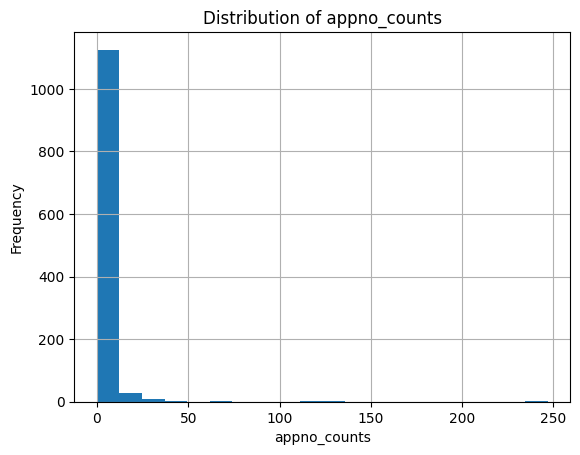

In [42]:
import matplotlib.pyplot as plt

test_data['appno_counts'].hist(bins=20)
plt.xlabel('appno_counts')
plt.ylabel('Frequency')
plt.title('Distribution of appno_counts')
plt.show()